[Streamlit](https://placement-and-salary-app-avsdnomqyvcyaggtaaxqnp.streamlit.app/)

https://placement-and-salary-app-avsdnomqyvcyaggtaaxqnp.streamlit.app/

Video

https://drive.google.com/drive/folders/1ZigVhH8PVlPkuM_lgu2EzVDuHBhsKN_G?usp=sharing

# I. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, accuracy_score, confusion_matrix,ConfusionMatrixDisplay, roc_auc_score, roc_curve,mean_squared_error, mean_absolute_error, r2_score, precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from xgboost import XGBClassifier, XGBRegressor
import random

In [2]:
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

In [3]:
df = pd.read_csv('B.csv')
df.head()

,student_id,gender,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,extracurricular_activities,placement_status,salary_package_lpa
0,1,Male,53,79,56,8.87,50,92,90,1,3,23,4,91,4,Yes,0,0.00
1,2,Female,56,54,59,6.78,61,51,99,1,0,6,5,87,3,No,0,0.00
2,3,Male,94,83,83,7.92,91,93,84,1,1,10,2,81,2,No,1,6.92
3,4,Male,84,71,87,6.57,85,60,72,4,2,14,5,87,3,No,0,0.00
4,5,Male,58,88,74,9.01,73,52,88,1,2,20,0,60,1,No,0,0.00


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  5000 non-null   int64  
 1   gender                      5000 non-null   object 
 2   ssc_percentage              5000 non-null   int64  
 3   hsc_percentage              5000 non-null   int64  
 4   degree_percentage           5000 non-null   int64  
 5   cgpa                        5000 non-null   float64
 6   entrance_exam_score         5000 non-null   int64  
 7   technical_skill_score       5000 non-null   int64  
 8   soft_skill_score            5000 non-null   int64  
 9   internship_count            5000 non-null   int64  
 10  live_projects               5000 non-null   int64  
 11  work_experience_months      5000 non-null   int64  
 12  certifications              5000 non-null   int64  
 13  attendance_percentage       5000 

In [5]:
df.describe()

,student_id,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,placement_status,salary_package_lpa
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,2500.500000,72.425800,71.910800,71.845200,7.678326,69.197800,69.651000,69.839600,1.987800,2.491800,11.982000,2.481000,79.433400,2.518400,0.173200,1.59589
std,1443.520003,13.199642,12.842781,10.013196,1.237084,17.325528,17.179704,17.170732,1.410975,1.704967,7.258114,1.719485,11.638585,1.721004,0.378458,3.77582
min,1.000000,50.000000,50.000000,55.000000,5.500000,40.000000,40.000000,40.000000,0.000000,0.000000,0.000000,0.000000,60.000000,0.000000,0.000000,0.00000
25%,1250.750000,61.000000,61.000000,63.000000,6.617500,54.000000,55.000000,55.000000,1.000000,1.000000,6.000000,1.000000,69.000000,1.000000,0.000000,0.00000
50%,2500.500000,72.000000,72.000000,72.000000,7.700000,69.000000,70.000000,69.000000,2.000000,3.000000,12.000000,2.000000,80.000000,3.000000,0.000000,0.00000
75%,3750.250000,84.000000,83.000000,80.000000,8.750000,84.000000,84.000000,85.000000,3.000000,4.000000,18.000000,4.000000,89.000000,4.000000,0.000000,0.00000
max,5000.000000,95.000000,94.000000,89.000000,9.800000,99.000000,99.000000,99.000000,4.000000,5.000000,24.000000,5.000000,99.000000,5.000000,1.000000,14.99000


# II. Exploratory Data Analysis (EDA)

### 2.1 Data Quality Checks

In [6]:
# Missing Value
print('Missing Value :')
print(df.isnull().sum())

# Duplicate
print(f'\nDuplicates :')
print(df.duplicated().sum())

# Inconsistent Value
print('\nCategorical Values:')
for col in ['gender', 'extracurricular_activities', 'placement_status']:
    print(f'{col}: {df[col].unique()}')

Missing Value :
student_id                    0
gender                        0
ssc_percentage                0
hsc_percentage                0
degree_percentage             0
cgpa                          0
entrance_exam_score           0
technical_skill_score         0
soft_skill_score              0
internship_count              0
live_projects                 0
work_experience_months        0
certifications                0
attendance_percentage         0
backlogs                      0
extracurricular_activities    0
placement_status              0
salary_package_lpa            0
dtype: int64

Duplicates :
0

Categorical Values:
gender: ['Male' 'Female']
extracurricular_activities: ['Yes' 'No']
placement_status: [0 1]


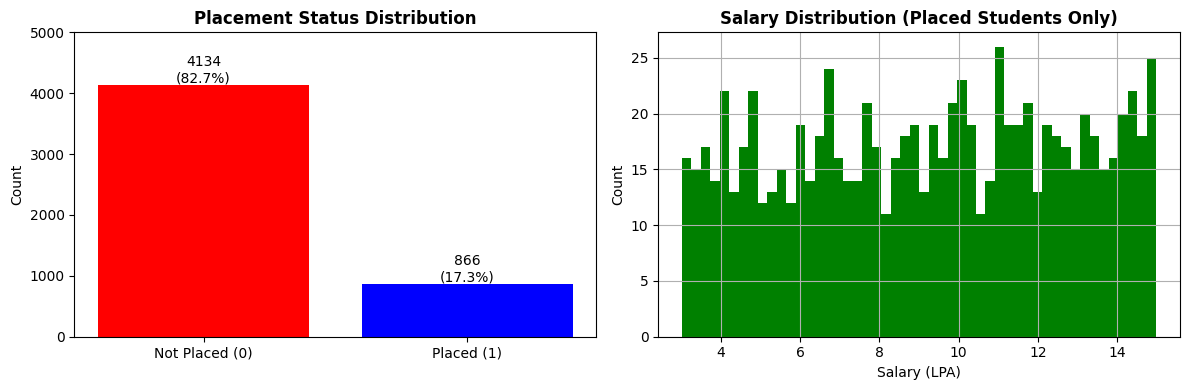

In [7]:
fig,ax= plt.subplots(1, 2, figsize=(12, 4))

# plot 1
ps = df['placement_status'].value_counts()
ax[0].bar(['Not Placed (0)', 'Placed (1)'], ps.values, color=['red', 'blue'])
for i, j in enumerate(ps.values):
    ax[0].text(i, j + 40, f'{j}\n({j/len(df)*100:.1f}%)', ha='center')
ax[0].set_ylim(0, 5000)
ax[0].set_title('Placement Status Distribution', fontweight = 'bold')
ax[0].set_ylabel('Count')

# plot 2
df[df['placement_status']==1]['salary_package_lpa'].hist(bins= 50, ax=ax[1], color='green')
ax[1].set_title('Salary Distribution (Placed Students Only)', fontweight='bold')
ax[1].set_xlabel('Salary (LPA)')
ax[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Plot Placement Status Distribution** menunjukkan distribusi kelas target klasifikasi. Dari output, data sangat imbalanced, yaitu sekitar 4134 siswa tidak ditempatkan (Not Placed) dan hanya 866 yang ditempatkan (Placed), dengan rasio mendekati 4.77:1.

**Plot Salary Distribution** menunjukkan distribusi gaji, tapi hanya untuk siswa yang berhasil placed. Plotnya terlihat mendekati normal, meskipun merata di seluruh bagian x-bar

### 2.2 Distribution & Skewness Analysis

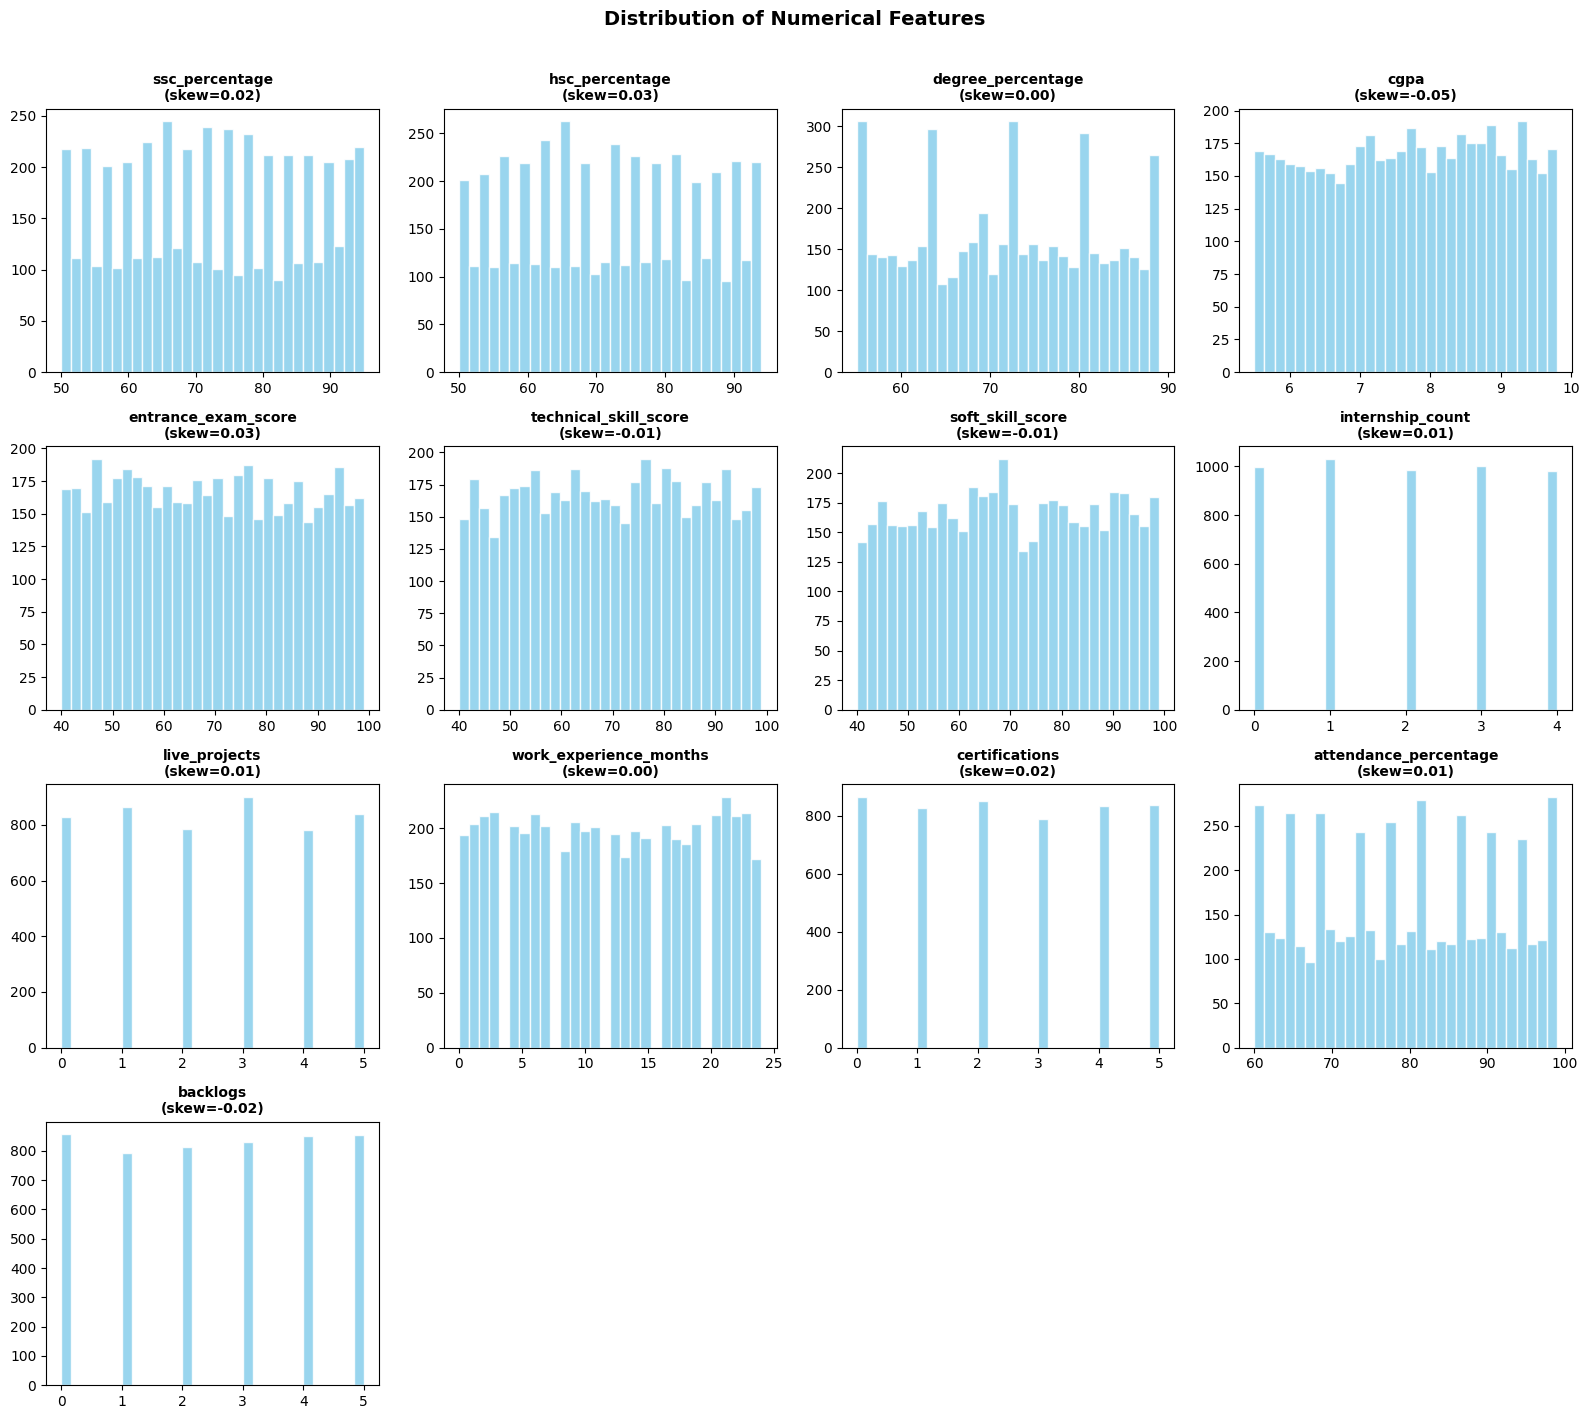

In [8]:
num_cols = df.select_dtypes(include=np.number).drop(columns=['student_id', 'placement_status', 'salary_package_lpa']).columns.tolist()

n=len(num_cols)
ncols =4
nrows =(n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='skyblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col}\n(skew={df[col].skew():.2f})', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribution of Numerical Features', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Hampir semua variabel memiliki skewness mendekati 0 artinya distribusi simetris. Ini penting untuk memahami apakah perlu transformasi atatu tidak


### 2.3 Outlier Check

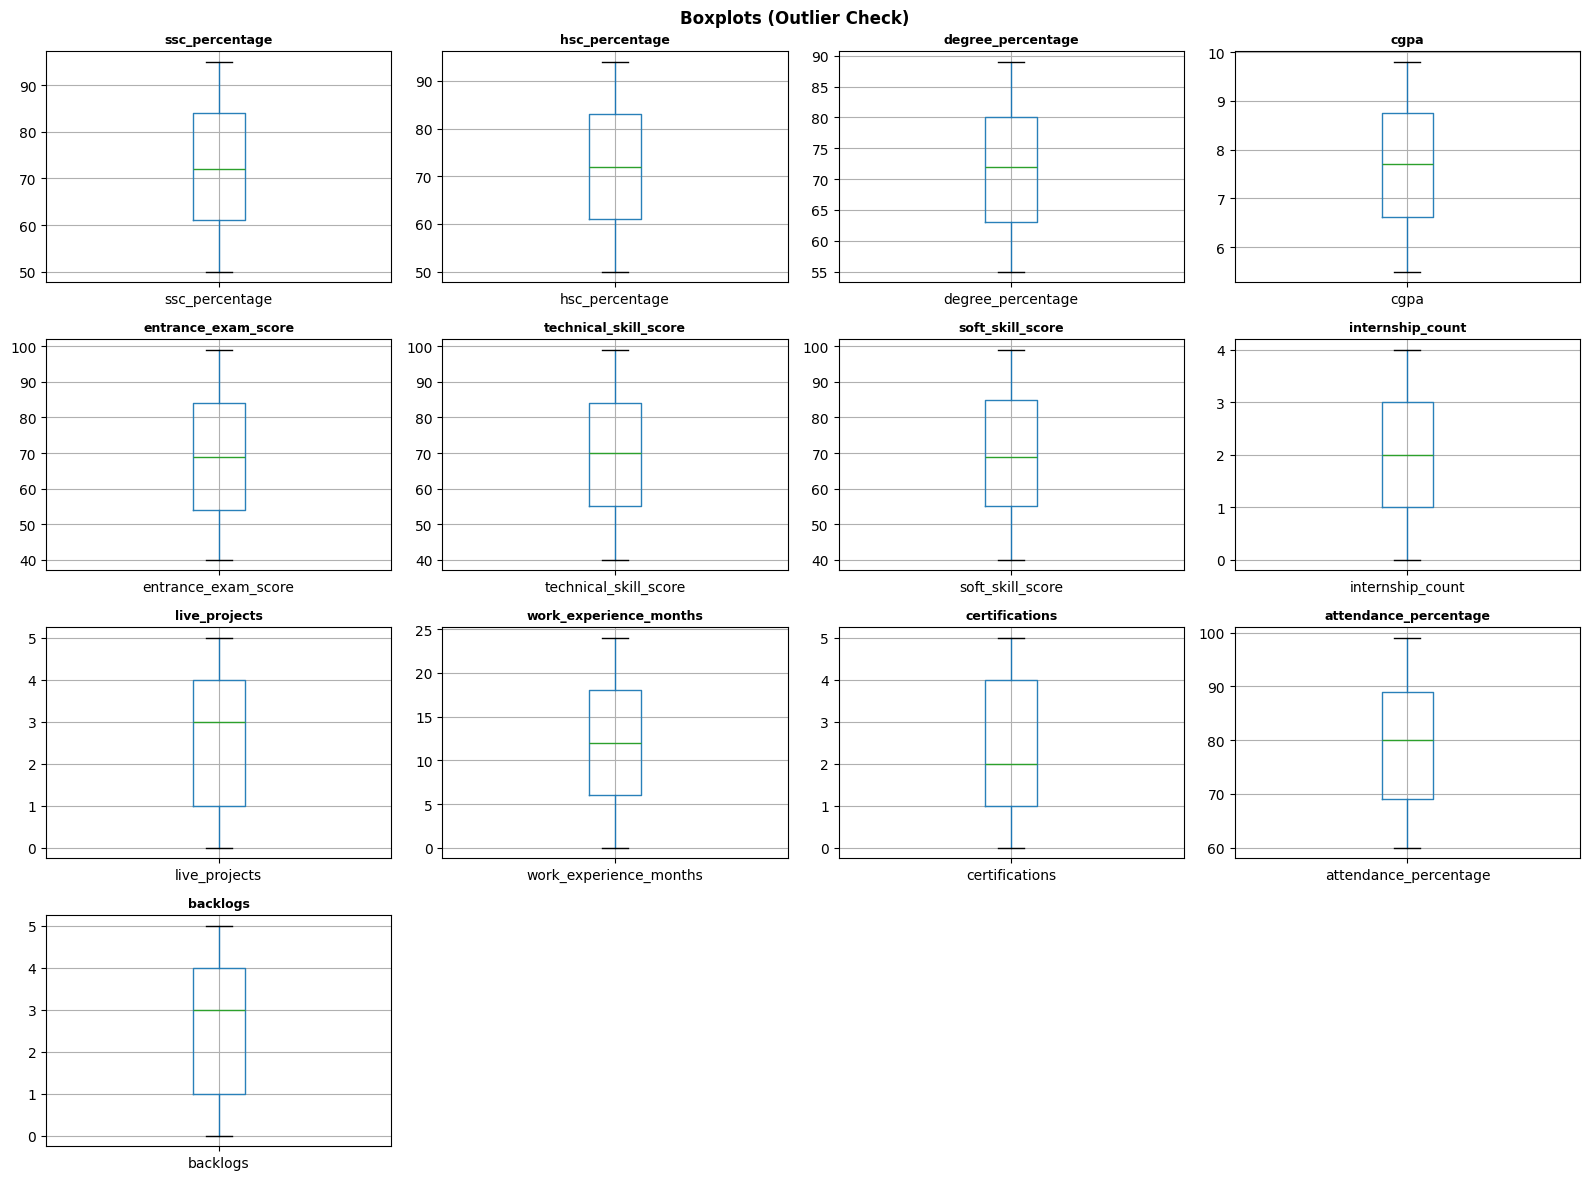

In [9]:
fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df.boxplot(column=col, ax=axes[i], vert=True,boxprops=dict(color='#2980b9'))
    axes[i].set_title(col, fontsize=9, fontweight='bold')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots (Outlier Check)', fontweight='bold')
plt.tight_layout()
plt.show()

Tidak ada outlier dari seluruh varibale yang ada, menandakan bahwa persebaran data cukup merata

### 2.4 Correlation Heatmap

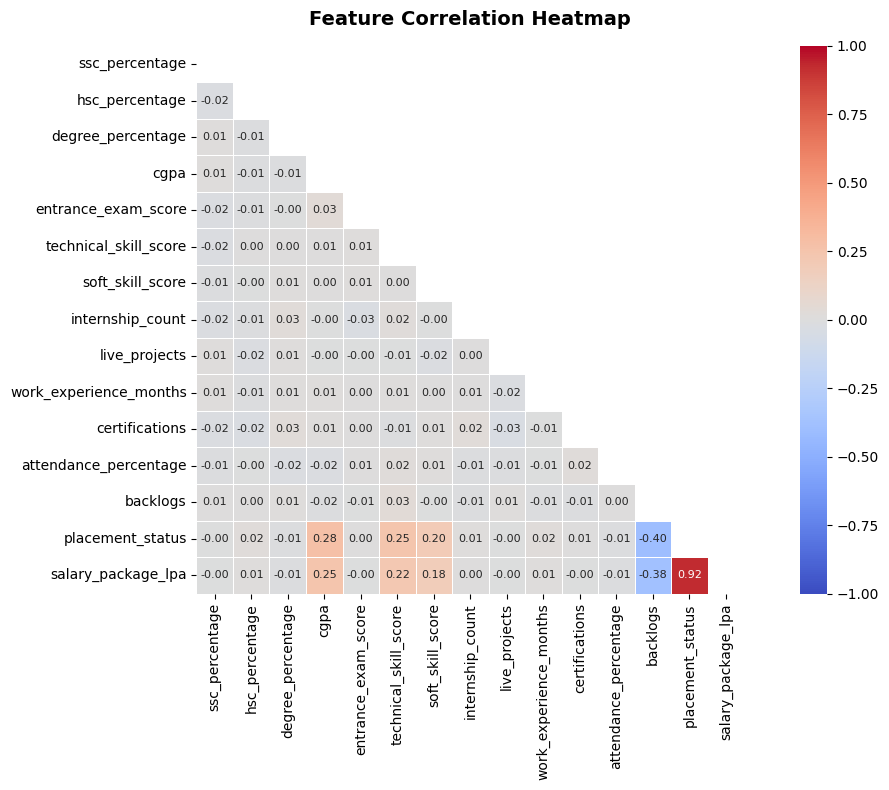

In [10]:
fig, ax = plt.subplots(figsize=(12, 8))
corr = df[num_cols + ['placement_status', 'salary_package_lpa']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            linewidths=0.5, ax=ax,annot_kws={'size': 8}, vmin=-1, vmax=1)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [11]:
# Top correlation
print('\nTop Features Correlated with placement_status:')
top_corr = corr['placement_status'].drop(['placement_status', 'salary_package_lpa']).abs().sort_values(ascending=False)
print(top_corr.head(5).to_string())

print('\nTop Features Correlated with salary_package_lpa:')
top_corr = corr['salary_package_lpa'].drop(['placement_status', 'salary_package_lpa']).abs().sort_values(ascending=False)
print(top_corr.head(5).to_string())


Top Features Correlated with placement_status:
backlogs                  0.401394
cgpa                      0.278728
technical_skill_score     0.246573
soft_skill_score          0.197685
work_experience_months    0.021453

Top Features Correlated with salary_package_lpa:
backlogs                 0.376909
cgpa                     0.249022
technical_skill_score    0.223200
soft_skill_score         0.182165
attendance_percentage    0.014698


- Hampir semua fitur saling tidak berkorelasi kuat -> mendekati 0. Artinya tiap variabel berdiri sendiri
- Korelasi terkuat adalah salary dengan placement_status, hal ini karena orang dapat placement, gajinya akan naik secara signifikan (!=0)
- cgpa, technical_skill_score, soft_skill_score → pengaruh lemah (0.18–0.25). Artinya berpegaruh, tapi tidak signifikan
- Backlogs, berkorelasi negatif ke placement (-0.40) dan salary (-0.38). Artinya, setiap pengulangan mata kuliah berpengaruh pada penerimaan kerja

### 2.5 Categorical & Relationship Plots

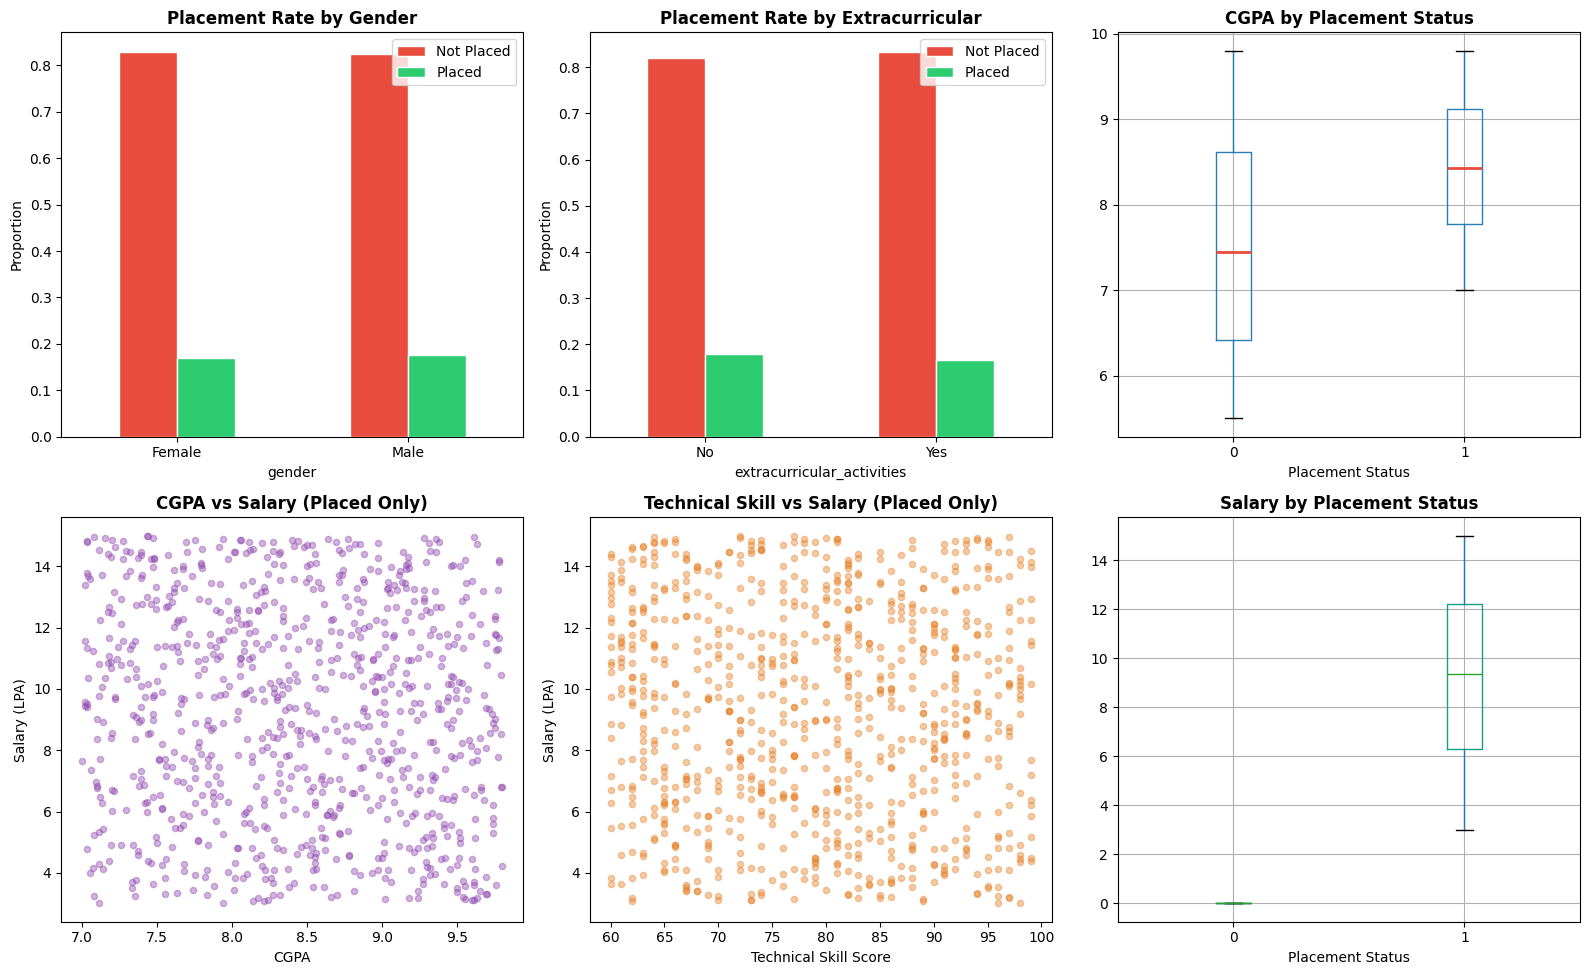

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Placement by Gender
pd.crosstab(df['gender'], df['placement_status'], normalize='index').plot(
    kind='bar', ax=axes[0, 0], color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[0, 0].set_title('Placement Rate by Gender', fontweight='bold')
axes[0, 0].set_ylabel('Proportion')
axes[0, 0].legend(['Not Placed', 'Placed'], loc='upper right')
axes[0, 0].tick_params(axis='x', rotation=0)

# Placement by Extracurricular
pd.crosstab(df['extracurricular_activities'], df['placement_status'], normalize='index').plot(
    kind='bar', ax=axes[0, 1], color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[0, 1].set_title('Placement Rate by Extracurricular', fontweight='bold')
axes[0, 1].set_ylabel('Proportion')
axes[0, 1].legend(['Not Placed', 'Placed'])
axes[0, 1].tick_params(axis='x', rotation=0)

# CGPA vs Placement
df.boxplot(column='cgpa', by='placement_status', ax=axes[0, 2],
           boxprops=dict(color='#2980b9'), medianprops=dict(color='#e74c3c', linewidth=2))
axes[0, 2].set_title('CGPA by Placement Status', fontweight='bold')
axes[0, 2].set_xlabel('Placement Status')
plt.sca(axes[0, 2])
plt.title('CGPA by Placement Status', fontweight='bold')

# CGPA vs Salary (placed only)
placed = df[df['placement_status'] == 1]
axes[1, 0].scatter(placed['cgpa'], placed['salary_package_lpa'],alpha=0.4, c='#8e44ad', s=20)
axes[1, 0].set_title('CGPA vs Salary (Placed Only)', fontweight='bold')
axes[1, 0].set_xlabel('CGPA')
axes[1, 0].set_ylabel('Salary (LPA)')

# Technical Skill vs Salary
axes[1, 1].scatter(placed['technical_skill_score'], placed['salary_package_lpa'],alpha=0.4, c='#e67e22', s=20)
axes[1, 1].set_title('Technical Skill vs Salary (Placed Only)', fontweight='bold')
axes[1, 1].set_xlabel('Technical Skill Score')
axes[1, 1].set_ylabel('Salary (LPA)')

# Work Experience vs Placement
df.boxplot(column='salary_package_lpa', by='placement_status', ax=axes[1, 2],boxprops=dict(color='#16a085'))
axes[1, 2].set_title('Salary by Placement', fontweight='bold')
axes[1, 2].set_xlabel('Placement Status')
plt.sca(axes[1, 2])
plt.title('Salary by Placement Status', fontweight='bold')

plt.suptitle('')
plt.tight_layout()
plt.show()

- Gender: Tidak terlihat perbedaan berarti antara laki-laki dan perempuan dalam hal placement. Jadi, gender bukan faktor penentu di data ini.
- Extracurricular: Partisipasi kegiatan extracurricular tidak menunjukkan pengaruh yang signifikan terhadap placement.
- CGPA vs Placement: Dari boxplot, kandidat yang placed cenderung punya CGPA lebih tinggi
- Salary vs Placement: Kandidat yang tidak placed, tidak punya salary, sementara yang placed punya distribusi gaji yang cukup lebar.
- CGPA vs Salary : Hubungannya tergolong lemah. CGPA tinggi tidak menjamin gaji lebih tinggi.
- Technical Skill vs Salary: Polanya juga cukup menyebar, jadi technichal skill belum cukup menjelaskan variasi gaji.

# III. Preprocessing

### 3.1 Cleaning

In [13]:
df_clean = df.copy()

# Drop student_id (unique identifier)
df_clean.drop(columns=['student_id'], inplace=True)

### 3.2 Encode Categorical Columns

In [14]:
# Binary encoding
df_clean['gender'] = df_clean['gender'].map({'Male': 1, 'Female': 0})
df_clean['extracurricular_activities'] = df_clean['extracurricular_activities'].map({'Yes': 1, 'No': 0})

In [15]:
df_clean['extracurricular_activities'].value_counts()

,count
extracurricular_activities,
0,2553
1,2447


In [16]:
df_clean['gender'].value_counts()

,count
gender,
1,2504
0,2496


### 3.3 Split (80% train, 20% test)

In [17]:
# Target
TARGET_CLF = 'placement_status'
TARGET_REG = 'salary_package_lpa'

# Feature (exclude leakage feature)
feature_cols = [c for c in df_clean.columns if c not in [TARGET_CLF, TARGET_REG]]

X = df_clean[feature_cols]
y_clf = df_clean[TARGET_CLF]
y_reg = df_clean[TARGET_REG]

# Stratified split on placement_status
X_train, X_test, y_clf_train, y_clf_test, y_reg_train, y_reg_test = train_test_split(
    X, y_clf, y_reg, test_size=0.2, random_state=SEED, stratify=y_clf
)

print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print(f'Train placement distribution:\n{y_clf_train.value_counts()}')
print(f'\nTest placement distribution:\n{y_clf_test.value_counts()}')

Train size: 4000 | Test size: 1000
Train placement distribution:
placement_status
0    3307
1     693
Name: count, dtype: int64

Test placement distribution:
placement_status
0    827
1    173
Name: count, dtype: int64


stratify memastikan proporsi data placed dan not placed di train dan test tetap sama seperti di dataset asli. Dengan begitu, distribusi bisa sama, sehingga model belajar dari data yang representatif dan hasil evaluasi menjadi lebih akurat (menghindari bias).

## IV. Feature Engineering

In [18]:
def engineer_features(df):
    df = df.copy()

    df['total_experience'] = (df['internship_count']+df['live_projects'] +(df['work_experience_months'] / 12))
    df['skill_score_combined'] = (df['technical_skill_score'] + df['soft_skill_score']) / 2
    df['academic_score_avg'] = (df['ssc_percentage'] + df['hsc_percentage']+df['degree_percentage']+df['cgpa'] * 10) / 4
    df['engagement_score'] = (df['attendance_percentage'] + df['extracurricular_activities'])

    return df

- total_experience: menyatukan internship, project, dan pengalaman kerja sehingga model bisa melihat gambaran pengalaman secara keseluruhan
- skill_score_combined: gabungkan technical + soft skill, agar lebih representatif untuk kemampuan kandidat secara general
- academic_score_avg: merangkum performa akademik dari berbagai jenjang
- engagement_score: menangkap tingkat keaktifan (attendance + kegiatan)

In [19]:
X_train_fe = engineer_features(X_train)
X_test_fe  = engineer_features(X_test)

new_features = ['total_experience', 'skill_score_combined', 'academic_score_avg', 'engagement_score']
print('New features created:')
X_train_fe[new_features].describe()

New features created:


,total_experience,skill_score_combined,academic_score_avg,engagement_score
count,4000.000000,4000.000000,4000.000000,4000.000000
mean,5.453354,69.804625,73.228194,79.988250
std,2.290433,12.220637,6.021410,11.633054
min,0.000000,40.000000,54.100000,60.000000
25%,3.833333,61.000000,69.050000,70.000000
50%,5.416667,70.000000,73.300000,80.000000
75%,7.083333,78.500000,77.475000,90.000000
max,11.000000,99.000000,92.475000,100.000000


## V. Scaling

In [20]:
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_fe),
    columns=X_train_fe.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test_fe),
    columns=X_test_fe.columns
)

print('\nSample scaled stats (train):')
X_train_scaled.describe()


Sample scaled stats (train):


,gender,ssc_percentage,hsc_percentage,degree_percentage,cgpa,entrance_exam_score,technical_skill_score,soft_skill_score,internship_count,live_projects,work_experience_months,certifications,attendance_percentage,backlogs,extracurricular_activities,total_experience,skill_score_combined,academic_score_avg,engagement_score
count,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03,4.000000e+03
mean,6.394885e-17,-4.334311e-16,5.213607e-16,-3.872458e-16,6.645795e-16,1.136868e-16,-4.130030e-16,2.184919e-16,2.398082e-17,1.456613e-16,8.881784e-17,-6.750156e-17,9.947598e-17,-7.105427e-17,7.904788e-17,1.723066e-16,-1.163514e-16,-4.383161e-16,5.511147e-16
std,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00,1.000125e+00
min,-1.002503e+00,-1.695435e+00,-1.708056e+00,-1.687066e+00,-1.760961e+00,-1.695939e+00,-1.718559e+00,-1.748223e+00,-1.406396e+00,-1.452951e+00,-1.642511e+00,-1.444050e+00,-1.677431e+00,-1.456569e+00,-9.743294e-01,-2.381225e+00,-2.439181e+00,-3.177094e+00,-1.718444e+00
25%,-1.002503e+00,-8.618040e-01,-8.518878e-01,-8.863226e-01,-8.618927e-01,-8.836591e-01,-8.490115e-01,-8.147016e-01,-6.988642e-01,-8.652469e-01,-8.157610e-01,-8.611840e-01,-8.172653e-01,-8.764939e-01,-9.743294e-01,-7.073875e-01,-7.205619e-01,-6.939763e-01,-8.587168e-01
50%,9.975031e-01,-2.817294e-02,4.280843e-03,1.451347e-02,1.692638e-02,-1.335911e-02,2.053581e-02,2.129596e-03,8.667260e-03,3.101607e-01,1.098888e-02,-2.783183e-01,4.290079e-02,2.836569e-01,-9.743294e-01,-1.601972e-02,1.598930e-02,1.192665e-02,1.010179e-03
75%,9.975031e-01,8.812428e-01,8.604495e-01,8.152566e-01,8.633466e-01,8.569409e-01,8.321133e-01,8.773059e-01,7.161987e-01,8.978644e-01,8.377388e-01,8.874129e-01,9.030669e-01,8.637323e-01,1.026347e+00,7.117358e-01,7.116210e-01,7.053725e-01,8.607372e-01
max,9.975031e-01,1.714874e+00,1.716618e+00,1.716093e+00,1.721916e+00,1.727241e+00,1.701661e+00,1.694137e+00,1.423730e+00,1.485568e+00,1.664489e+00,1.470279e+00,1.677216e+00,1.443808e+00,1.026347e+00,2.421961e+00,2.389321e+00,3.196795e+00,1.720464e+00


Scaling dilakukan supaya semua fitur berada di skala yang sama, sehingga tidak ada fitur dengan nilai besar yang mendominasi model (lebih berpengaruh pada model)

## VI. Modeling

### 6.1 Classification Model

In [21]:
X_clf_train = X_train_scaled.copy()
X_clf_test  = X_test_scaled.copy()

In [22]:
# scale pos weight for XGBoost
pos_weight = (y_clf_train == 0).sum() / (y_clf_train == 1).sum()

# Parameter Grid
clf_configs = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, random_state=SEED, class_weight='balanced'),
        {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']}
    ),
    'LightGBM': (
        LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1, class_weight='balanced'),
        {'n_estimators': [100, 200], 'max_depth': [5, 8, -1],
         'learning_rate': [0.05, 0.1, 0.2], 'num_leaves': [31, 63]}
    ),
    'Random Forest': (
        RandomForestClassifier(random_state=SEED, n_jobs=-1, class_weight='balanced'),
        {'n_estimators': [100, 200], 'max_depth': [6, 10, None],
         'min_samples_split': [2, 5], 'max_features': ['sqrt', 'log2']}
    ),
    'XGBoost': (
        XGBClassifier(random_state=SEED, n_jobs=-1, eval_metric='logloss', verbosity=0, scale_pos_weight=pos_weight),
        {'n_estimators': [100, 200], 'max_depth': [4, 6, 8],
         'learning_rate': [0.05, 0.1, 0.2], 'subsample': [0.8, 1.0]}
    )
}

Alasan Pemilihan Model :
- Logistic Regression dipakai sebagai baseline. Model ini sederhana dan dijadikan acuan awal untuk lihat performa minimal.
- Tree-based models (Random Forest, LightGBM, XGBoost) karena model ini mampu menangkap hubungan non-linear antar fitur. Selain itu, secara praktik, sering memberikan performa yang lebih baik di data tabular
- Random Forest -> stabil dan relatif robust, cocok sebagai pembanding awal di model tree
- LightGBM & XGBoost -> boosting-based, biasanya lebih kuat karena belajar dari error model sebelumnya, sehingga performanya sering lebih tinggi

In [23]:
clf_results = {}
best_clf_models = {}

for name, (model, params) in clf_configs.items():
    n_iter_search = 8 if name == 'Logistic Regression' else 12

    search = RandomizedSearchCV(
        model, params, n_iter=n_iter_search, cv=5,
        scoring={'Accuracy': 'accuracy','F1': 'f1','AUC': 'roc_auc'},
        refit='F1',
        n_jobs=-1, random_state=SEED
    )

    search.fit(X_clf_train, y_clf_train)

    best_model = search.best_estimator_
    best_clf_models[name] = best_model

    best_index = search.best_index_
    cv_acc = search.cv_results_['mean_test_Accuracy'][best_index]
    cv_f1  = search.cv_results_['mean_test_F1'][best_index]
    cv_auc = search.cv_results_['mean_test_AUC'][best_index]

    clf_results[name] = {'CV_Accuracy': cv_acc, 'CV_F1': cv_f1, 'CV_AUC': cv_auc, 'Best Params': search.best_params_}

    print(f'\n[{name}]')
    print(f'CV Accuracy={cv_acc:.4f} | CV F1={cv_f1:.4f} | CV AUC={cv_auc:.4f}')
    print(f'Best params: {search.best_params_}')


[Logistic Regression]
CV Accuracy=0.8372 | CV F1=0.6486 | CV AUC=0.9305
Best params: {'solver': 'lbfgs', 'C': 10}

[LightGBM]
CV Accuracy=0.9998 | CV F1=0.9993 | CV AUC=0.9998
Best params: {'num_leaves': 63, 'n_estimators': 200, 'max_depth': -1, 'learning_rate': 0.2}

[Random Forest]
CV Accuracy=0.9995 | CV F1=0.9986 | CV AUC=1.0000
Best params: {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 10}

[XGBoost]
CV Accuracy=0.9992 | CV F1=0.9978 | CV AUC=0.9999
Best params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.2}


- Logistic Regression:
Model ini mampu memprediksi +- 83% data dengan benar. Namun, skor harmoninya rendah di angka 64.8, kemungkinan besar karena model kesulitan mengenali kelas data yang jumlahnya sedikit atau polanya terlalu rumit.

- LightGBM, Random Forest, dan XGBoost:
Ketiga model ini menunjukkan hasil yang hampir sempurna dengan nilai mendekati 1 di semua kategori. Secara teknis, ketiganya mampu memprediksi data dengan sangat akurat tanpa celah.

- Adanya indikasi kuat bahwa data yang digunakan terlalu mudah ditebak atau terdapat anomali. Hasil yang terlalu sempurna ini berisiko menyebabkan model overfit


### 6.2 Regression Model


In [24]:
# Filter (only placed students)
placed_train_mask = y_clf_train.values == 1
placed_test_mask  = y_clf_test.values == 1

X_reg_train = X_train_scaled[placed_train_mask].copy()
X_reg_test  = X_test_scaled[placed_test_mask].copy()

y_reg_train_f = y_reg_train[placed_train_mask]
y_reg_test_f  = y_reg_test[placed_test_mask]

print(f'Regression train size: {X_reg_train.shape[0]}')
print(f'Regression test size : {X_reg_test.shape[0]}')

Regression train size: 693
Regression test size : 173


Kode ini bertujuan membuang data leakage karena mahasiswa yang tidak bekerja otomatis memiliki gaji nol sehingga data tersebut sangat mudah ditebak model. Filter dilakukan agar model regresi hanya belajar dari data mahasiswa yang sudah pasti memiliki pekerjaan atau gaji.

In [25]:
# Parameter Grid
reg_configs = {
    'Linear Regression': (
        LinearRegression(),
        {'fit_intercept': [True, False]}
    ),
    'Random Forest': (
        RandomForestRegressor(random_state=SEED, n_jobs=-1),
        {'n_estimators': [100, 200], 'max_depth': [6, 10, None],
         'min_samples_split': [2, 5], 'max_features': ['sqrt', 'log2']}
    ),
    'LightGBM': (
        LGBMRegressor(random_state=SEED, n_jobs=-1, verbose=-1),
        {'n_estimators': [100, 200], 'max_depth': [5, 8, -1],
         'learning_rate': [0.05, 0.1, 0.2], 'num_leaves': [31, 63]}
    ),
    'XGBoost': (
        XGBRegressor(random_state=SEED, n_jobs=-1, verbosity=0),
        {'n_estimators': [100, 200], 'max_depth': [4, 6, 8],
         'learning_rate': [0.05, 0.1, 0.2], 'subsample': [0.8, 1.0]}
    )
}

Alasan pemilihan Model:
- Linear Regression digunakan sebagai baseline atau acuan awal untuk melihat performa prediksi paling sederhana
- Random Forest dipilih karena sifatnya yang stabil dan robust sebagai pembanding kuat di kategori tree based model
- LightGBM dan XGBoost diandalkan untuk mengejar performa lebih tinggi karena kemampuannya belajar dari kesalahan prediksi sebelumnya secara efisien

In [26]:
reg_results = {}
best_reg_models = {}

for name, (model, params) in reg_configs.items():
    n_iter = 2 if name == 'Linear Regression' else 12

    search = RandomizedSearchCV(
        model, params, n_iter=n_iter, cv=5,
        scoring={'RMSE': 'neg_root_mean_squared_error', 'MAE': 'neg_mean_absolute_error', 'R2': 'r2'},
        refit='MAE',
        n_jobs=-1, random_state=SEED
    )

    search.fit(X_reg_train, y_reg_train_f)
    best_model = search.best_estimator_
    best_reg_models[name] = best_model

    best_index = search.best_index_
    rmse = -search.cv_results_['mean_test_RMSE'][best_index]
    mae  = -search.cv_results_['mean_test_MAE'][best_index]
    r2   = search.cv_results_['mean_test_R2'][best_index]

    reg_results[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2, 'Best Params': search.best_params_}

    print(f'\n[{name}]')
    print(f'RMSE={rmse:.4f} | MAE={mae:.4f} | R²={r2:.4f}')
    print(f'Best params: {search.best_params_}')


[Linear Regression]
RMSE=3.5573 | MAE=3.0781 | R²=-0.0381
Best params: {'fit_intercept': True}

[Random Forest]
RMSE=3.5264 | MAE=3.0441 | R²=-0.0201
Best params: {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 6}

[LightGBM]
RMSE=3.7863 | MAE=3.1841 | R²=-0.1767
Best params: {'num_leaves': 63, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}

[XGBoost]
RMSE=3.6924 | MAE=3.1406 | R²=-0.1186
Best params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 8, 'learning_rate': 0.05}


- Linear Regression: Model ini digunakan sebagai baseline, namun hasilnya sangat buruk karena nilai R-Squared negatif. Artinya, model ini gagal menangkap pola data dan prediksinya bahkan lebih buruk daripada sekadar menggunakan nilai rata-rata gaji.

- Random Forest, LightGBM, dan XGBoost:
Ketiga model berbasis pohon ini juga gagal memberikan hasil yang memuaskan dengan nilai R-Squared yang semuanya negatif. Skor error (RMSE dan MAE) yang cukup tinggi menunjukkan bahwa model-model ini pun kesulitan memprediksi besaran gaji secara akurat.

- Hasil ini menunjukkan bahwa variabel tidak punya hubungan linier maupun non-linier yang kuat dengan gaji. Ada indikasi bahwa data gaji memiliki variansi yang terlalu acak atau fitur yang tersedia memang tidak cukup untuk menjelaskan besar kecilnya gaji seseorang.

## VII. Evaluation & Model Comparison

### 7.1 Classification - Comparison Table

In [27]:
clf_test_results = {}

for name, model in best_clf_models.items():
    y_pred_test = model.predict(X_clf_test)
    y_prob_test = model.predict_proba(X_clf_test)[:, 1]

    test_acc = accuracy_score(y_clf_test, y_pred_test)
    test_f1 = f1_score(y_clf_test, y_pred_test)
    test_auc = roc_auc_score(y_clf_test, y_prob_test)

    clf_test_results[name] = {'Test_Accuracy': test_acc, 'Test_F1': test_f1, 'Test_AUC': test_auc}

clf_test_df = pd.DataFrame(clf_test_results).T.astype(float).round(4)
clf_test_df.sort_values('Test_F1', ascending=False, inplace=True)

print('Classification Model Comparison (Test Data)')
print(clf_test_df.to_string())

best_clf_name = clf_test_df['Test_F1'].idxmax()
print(f'\nBest Classification Model (Test): {best_clf_name} | F1 = {clf_test_df.loc[best_clf_name, "Test_F1"]:.4f}')

Classification Model Comparison (Test Data)
                     Test_Accuracy  Test_F1  Test_AUC
LightGBM                     1.000   1.0000    1.0000
Random Forest                1.000   1.0000    1.0000
XGBoost                      1.000   1.0000    1.0000
Logistic Regression          0.839   0.6538    0.9353

Best Classification Model (Test): LightGBM | F1 = 1.0000


- LightGBM, Random Forest, dan XGBoost:
Ketiga model tree based ini memberikan hasil yang sempurna dengan skor 1 di seluruh metrik evaluasi. Hal ini menunjukkan konsistensi dengan hasil training, di mana model mampu memprediksi semua data test dengan akurasi mutlak tanpa kesalahan.

- Logistic Regression:
Model ini memiliki performa yang tetap stabil di angka delapan puluh empat persen, namun masih tertinggal jauh di belakang model lainnya. Rendahnya skor F1 pada data test ini menegaskan bahwa model linear memang tidak cukup kuat untuk menangkap pola yang ada.

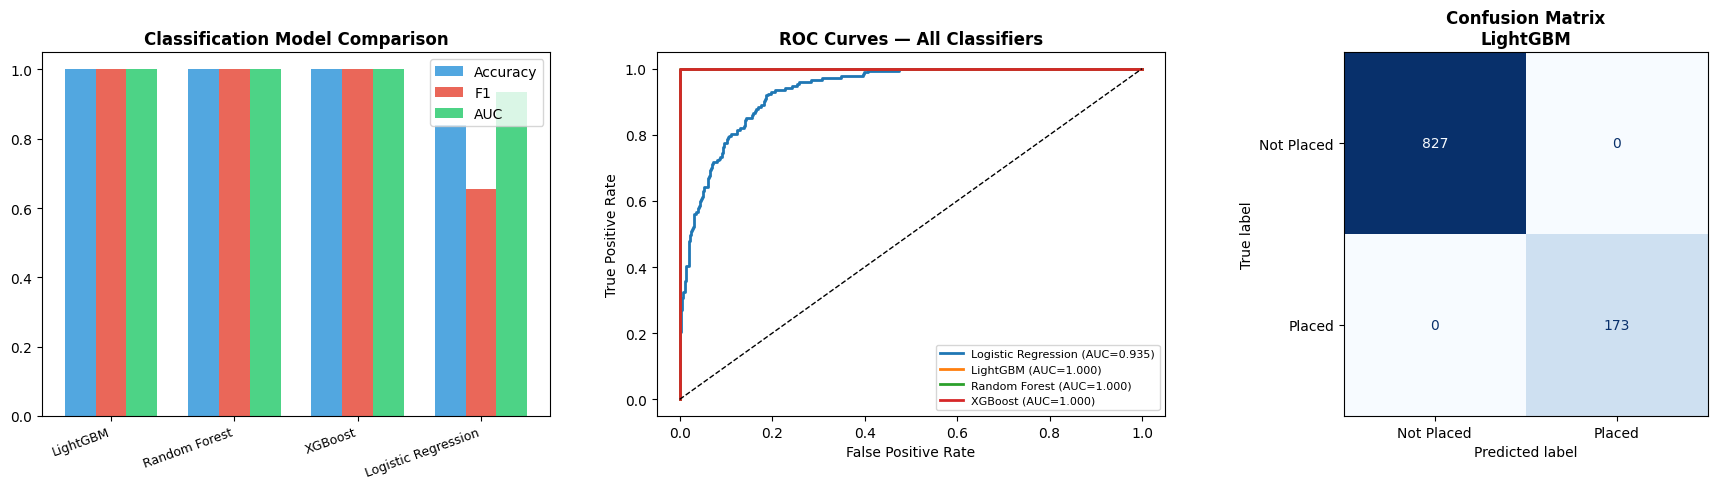


Classification Report of LightGBM:
              precision    recall  f1-score   support

  Not Placed       1.00      1.00      1.00       827
      Placed       1.00      1.00      1.00       173

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar plot comparison
metrics_to_plot = ['Test_Accuracy', 'Test_F1', 'Test_AUC']
x = np.arange(len(clf_test_df))
width = 0.25
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    bars = axes[0].bar(x + i * width, clf_test_df[metric], width, label=metric.replace('Test_', ''), color=color, alpha=0.85)

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(clf_test_df.index, rotation=20, ha='right', fontsize=9)
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].set_title('Classification Model Comparison', fontweight='bold')

# ROC Curves
for name, model in best_clf_models.items():
    y_prob = model.predict_proba(X_clf_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_clf_test, y_prob)
    auc = roc_auc_score(y_clf_test, y_prob)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — All Classifiers', fontweight='bold')
axes[1].legend(fontsize=8)

# Confusion matrix (best model)
best_clf = best_clf_models[best_clf_name]
y_pred_best = best_clf.predict(X_clf_test)
cm = confusion_matrix(y_clf_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=['Not Placed', 'Placed'])
disp.plot(ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title(f'Confusion Matrix\n{best_clf_name}', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\nClassification Report of {best_clf_name}:')
print(classification_report(y_clf_test, y_pred_best, target_names=['Not Placed', 'Placed']))

- Performa Model Tree-Based:
Grafik batang dan kurva ROC menunjukkan bahwa LightGBM, Random Forest, dan XGBoost mencapai skor sempurna sebesar satu. Hal ini dikonfirmasi oleh Confusion Matrix yang menunjukkan nol kesalahan prediksi (zero false positives/negatives).

- Performa Logistic Regression:
Berdasarkan kurva ROC, model ini tertinggal dengan nilai AUC sebesar 0.935. Meskipun hasilnya tergolong bagus secara statistik, model ini masih kalah dibandingkan model tree based dalam membedakan kategori data.

Akurasi yang mencapai seratus persen ini memperkuat dugaan bahwa data yang digunakan bersifat sintetis. Karena sebaran datanya menyebar rata tanpa pola alami yang signifikan, model-model canggih ini akhirnya hanya memetakan data secara kaku atau menghafal posisi titik data yang terlalu mudah dibedakan.

### 7.3 Regression - Comparison Table

In [29]:
reg_test_results = {}

for name, model in best_reg_models.items():
    y_pred_test_reg = model.predict(X_reg_test)

    test_rmse = np.sqrt(mean_squared_error(y_reg_test_f, y_pred_test_reg))
    test_mae = mean_absolute_error(y_reg_test_f, y_pred_test_reg)
    test_r2 = r2_score(y_reg_test_f, y_pred_test_reg)

    reg_test_results[name] = {'Test_RMSE': test_rmse, 'Test_MAE': test_mae, 'Test_R2': test_r2}

reg_test_df = pd.DataFrame(reg_test_results).T.astype(float).round(4)
reg_test_df.sort_values('Test_MAE', ascending=True, inplace=True)

print('\nRegression Model Comparison (Test Data)')
print(reg_test_df.to_string())

best_reg_name = reg_test_df['Test_MAE'].idxmin()
print(f'\nBest Regression Model (Test): {best_reg_name} | MAE = {reg_test_df.loc[best_reg_name, "Test_MAE"]:.4f}')


Regression Model Comparison (Test Data)
                   Test_RMSE  Test_MAE  Test_R2
Linear Regression     3.4056    2.9031  -0.0196
Random Forest         3.4233    2.9240  -0.0303
XGBoost               3.5904    3.0128  -0.1332
LightGBM              3.6883    3.1412  -0.1959

Best Regression Model (Test): Linear Regression | MAE = 2.9031


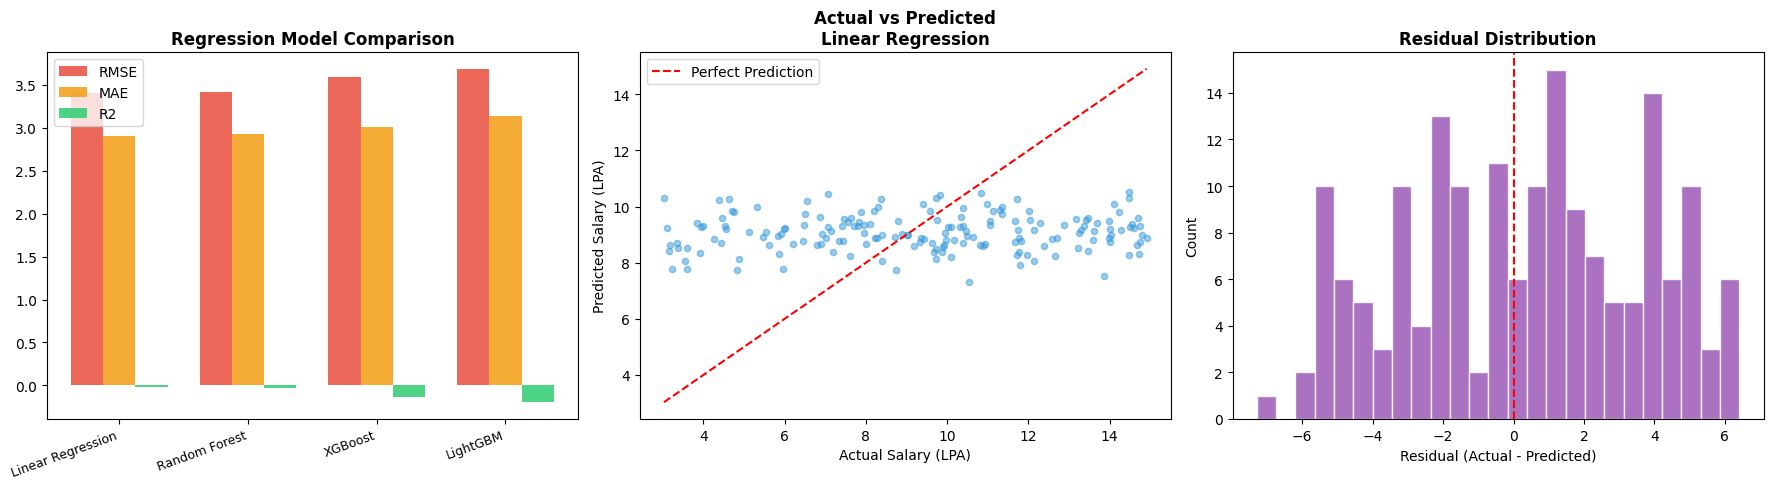

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Bar plot comparison
colors = ['#e74c3c', '#f39c12', '#2ecc71']
test_metrics_reg = ['Test_RMSE', 'Test_MAE', 'Test_R2']

for i, (metric, color) in enumerate(zip(test_metrics_reg, colors)):
    bars = axes[0].bar(np.arange(len(reg_test_df)) + i * 0.25,reg_test_df[metric], 0.25, label=metric.replace('Test_', ''), color=color, alpha=0.85)
axes[0].set_xticks(np.arange(len(reg_test_df)) + 0.25)
axes[0].set_xticklabels(reg_test_df.index, rotation=20, ha='right', fontsize=9)
axes[0].legend()
axes[0].set_title('Regression Model Comparison', fontweight='bold')

# Actual vs Predicted (best model)
best_reg = best_reg_models[best_reg_name]
y_pred_reg = best_reg.predict(X_reg_test)

axes[1].scatter(y_reg_test_f, y_pred_reg, alpha=0.5, c='#3498db', s=20)
min_val = min(y_reg_test_f.min(), y_pred_reg.min())
max_val = max(y_reg_test_f.max(), y_pred_reg.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')
axes[1].set_xlabel('Actual Salary (LPA)')
axes[1].set_ylabel('Predicted Salary (LPA)')
axes[1].set_title(f'Actual vs Predicted\n{best_reg_name}', fontweight='bold')
axes[1].legend()

# Residuals
residuals = y_reg_test_f - y_pred_reg
axes[2].hist(residuals, bins=25, color='#9b59b6', edgecolor='white', alpha=0.85)
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].set_xlabel('Residual (Actual - Predicted)')
axes[2].set_ylabel('Count')
axes[2].set_title('Residual Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

- Linear Regression:
Model ini menjadi yang terbaik di antara yang lain, namun tetap gagal memberikan prediksi yang valid karena nilai R-Squared yang negatif. Artinya, performa model linear ini lebih buruk daripada sekadar menggunakan nilai rata-rata untuk menebak gaji.

- Random Forest, XGBoost, dan LightGBM:
Ketiga model berbasis pohon ini memberikan hasil yang lebih buruk dibandingkan baseline dengan tingkat error yang lebih tinggi. Nilai R-Squared yang semakin menjauh ke angka negatif menunjukkan bahwa model-model canggih ini justru semakin bingung dalam memetakan pola data gaji.

- Scatter plot yang menyebar rata secara horizontal tanpa pola jelas membuktikan bahwa data ini bersifat sintetis dan acak. Grafik Residual Distribution yang berantakan juga menegaskan bahwa tidak ada hubungan logis antar fitur, sehingga model apapun tidak akan bisa memprediksi gaji secara akurat.

Hasil ini membuktikan bahwa data gaji tidak memiliki pola yang logis atau bersifat acak karena merupakan data sintetis. Karena sebaran data pada grafik menyebar rata tanpa pola signifikan, model tidak mampu menemukan hubungan antar variabel sehingga gagal total dalam memberikan prediksi yang akurat

**Pemilihan Best Model: Random Forest Regressor**

Meskipun secara angka metrik (MAE) Linear Regression sedikit lebih unggul (sebesar 0.02 di data test), saya memutuskan untuk menggunakan Random Forest Regressor untuk model yang nantinya dideploy. Alasannya, berdasarkan analisis visual 'Actual vs Predicted', Linear Regression gagal menangkap varians data dan cenderung menebak nilai rata-rata untuk semua kandidat (membentuk garis horizontal). Karakteristik fitur kandidat (seperti skor akademik dan pengalaman) bersifat sangat non-linear terhadap gaji, sehingga model berbasis tree seperti Random Forest akan lebih masuk akal dan aman untuk dideploy untuk menerima data-data baru di masa depan